# 03 - Explainable AI and Retention Recommendations

**Owner:** Gurnoor

**Scope:** This notebook does not retrain, re-tune, or re-select the churn model. It loads the model artifact produced in `02_modeling.ipynb` (final tuned XGBoost, decision threshold = 0.30) and builds the explainability and retention-recommendation layer on top of it:

Customer Data -> Preprocessing -> Churn Prediction -> Churn Probability -> SHAP Explanation -> Human-Readable Churn Reasons -> Retention Recommendation -> (Dashboard, owned by Ujjwal)

**Status:** Scaffold only. Sections are filled in incrementally, one at a time, and each stage is tested before moving to the next.

## 1. Load Model and Configuration

**Finding (before writing any code below):** `models/` originally contained only `model_config.json` (`{"threshold": 0.3}`). There was no `churn_model.pkl` / `xgboost_model.pkl` committed to the repo, because `models/*.pkl` is gitignored by design, and `02_modeling.ipynb` builds `final_pipeline = Pipeline([("preprocessor", preprocessor), ("model", xgb_model)])` and fits it (cell 25) but never calls `joblib.dump` on it — only the raw `xgb_model` (fit on already-preprocessed arrays) gets saved, to `../models/xgboost_model.pkl`, which is also gitignored and therefore not present locally either.

**Resolution used here:** rather than inventing a model or skipping ahead, the exact steps from `02_modeling.ipynb` were reproduced line-for-line (same 20 features, same `Total Charges` numeric coercion, same `train_test_split(test_size=0.20, random_state=42, stratify=y)`, same `ColumnTransformer` (`StandardScaler` on 4 numeric features, `OneHotEncoder(handle_unknown="ignore")` on 16 categorical features), same `XGBClassifier` hyperparameters) and the resulting `final_pipeline` was persisted to `models/churn_model.pkl`. This is **not** a new/retrained model — it is Gracy's exact pinned configuration, just actually saved to disk (which her notebook currently omits).

**Verification against Gracy's reported numbers:**
- Train/test shapes match exactly: 5634 / 1409 rows, 20 raw features -> 47 processed features.
- At threshold 0.30 on the test set: Accuracy ≈ 0.762, Precision(churn) ≈ 0.54, Recall(churn) ≈ 0.78, F1(churn) ≈ 0.63, churners predicted = 541/1409 — matches `results/threshold_analysis.csv` (0.5399 / 0.7781 / 0.6375 at threshold 0.30) and the reported ~538/1409 within rounding/library-version noise.
- At the default 0.50 threshold: Accuracy ≈ 0.807, ROC-AUC ≈ 0.857, vs. Gracy's reported 0.8034 / 0.8555 in `results/model_comparison.csv` — a small (~0.3-1pt) discrepancy, most likely from `xgboost`/`scikit-learn` minor version differences (this environment: xgboost 3.2.0, scikit-learn 1.9.0) rather than a different model. **This notebook does not overwrite `results/model_comparison.csv` or any other existing result file** — those numbers remain Gracy's official reported metrics. Anywhere this notebook restates them, it cites the file, not a re-measurement.

**Artifact structure:** `models/churn_model.pkl` is a full `sklearn.pipeline.Pipeline` with two named steps — `"preprocessor"` (the `ColumnTransformer`) and `"model"` (the fitted `XGBClassifier`) — so it accepts **raw, unprocessed customer records** (the 20 original feature columns) directly; preprocessing does not need to be reapplied by hand before calling `.predict()` / `.predict_proba()`. This matters for the SHAP setup in Section 4: SHAP's `TreeExplainer` needs the trees' native input space, so it will be pointed at `pipeline.named_steps["model"]` and fed data already run through `pipeline.named_steps["preprocessor"].transform(...)`, not the raw pipeline itself.

### 1a. One-time artifact regeneration (reproduces Gracy's pipeline; run only if `models/churn_model.pkl` is missing)

This cell is **not** the XAI workflow itself — it is a stopgap that reproduces the exact preprocessing + XGBoost configuration from `02_modeling.ipynb` and persists it, because that notebook currently fits `final_pipeline` but never saves it. Ideally this save step gets added directly to `02_modeling.ipynb` by Gracy so this cell becomes unnecessary; until then it is guarded to skip if the artifact already exists, so it never silently retrains over a real saved model.

In [1]:
import os
import joblib
import pandas as pd

MODEL_PATH = "../models/churn_model.pkl"
DATA_PATH = "../data/Telco_customer_churn.xlsx"

if not os.path.exists(MODEL_PATH):
    from sklearn.model_selection import train_test_split
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.pipeline import Pipeline
    from xgboost import XGBClassifier

    df = pd.read_excel(DATA_PATH)

    features = [
        "Gender", "Senior Citizen", "Partner", "Dependents", "Tenure Months",
        "Phone Service", "Multiple Lines", "Internet Service", "Online Security",
        "Online Backup", "Device Protection", "Tech Support", "Streaming TV",
        "Streaming Movies", "Contract", "Paperless Billing", "Payment Method",
        "Monthly Charges", "Total Charges", "CLTV",
    ]
    numeric_features = ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV"]
    categorical_features = [f for f in features if f not in numeric_features]

    df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
    X = df[features]
    y = df["Churn Value"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop=None), categorical_features),
    ])

    xgb_model = XGBClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.03, subsample=0.8,
        colsample_bytree=1.0, min_child_weight=1, eval_metric="logloss",
        random_state=42, n_jobs=-1,
    )

    final_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", xgb_model),
    ])
    final_pipeline.fit(X_train, y_train)

    joblib.dump(final_pipeline, MODEL_PATH)
    print(f"Regenerated and saved pipeline to {MODEL_PATH}")
else:
    print(f"{MODEL_PATH} already exists — skipping regeneration.")

../models/churn_model.pkl already exists — skipping regeneration.


### 1b. Load the model artifact and threshold config (actual Section 1 workflow)

In [2]:
import json

CONFIG_PATH = "../models/model_config.json"

churn_pipeline = joblib.load(MODEL_PATH)

with open(CONFIG_PATH) as f:
    model_config = json.load(f)

CHURN_THRESHOLD = model_config["threshold"]

print("Loaded object type:", type(churn_pipeline))
print("Pipeline steps:", list(churn_pipeline.named_steps.keys()))
print("Preprocessor:", churn_pipeline.named_steps["preprocessor"])
print("Model:", type(churn_pipeline.named_steps["model"]))
print("Decision threshold (from model_config.json):", CHURN_THRESHOLD)

Loaded object type: <class 'sklearn.pipeline.Pipeline'>
Pipeline steps: ['preprocessor', 'model']
Preprocessor: ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Tenure Months', 'Monthly Charges',
                                  'Total Charges', 'CLTV']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Gender', 'Senior Citizen', 'Partner',
                                  'Dependents', 'Phone Service',
                                  'Multiple Lines', 'Internet Service',
                                  'Online Security', 'Online Backup',
                                  'Device Protection', 'Tech Support',
                                  'Streaming TV', 'Streaming Movies',
                                  'Contract', 'Paperless Billing',
                                  'Payment Method'])])
Model: <class 'xgboost.sklearn.XGBClassifier'>
Decision threshold (from mode

## 2. Load / Prepare Customer Data

This section prepares the customer records the rest of the notebook will explain. It reuses the **same train/test split** as `02_modeling.ipynb` (`test_size=0.20, random_state=42, stratify=y`) so that the customers used for XAI examples are genuinely held-out test customers, not rows the model was trained on. `CustomerID` is kept alongside the 20 modeling features purely for display/lookup — it is never passed into the pipeline as a feature.

In [3]:
from sklearn.model_selection import train_test_split

FEATURES = [
    "Gender", "Senior Citizen", "Partner", "Dependents", "Tenure Months",
    "Phone Service", "Multiple Lines", "Internet Service", "Online Security",
    "Online Backup", "Device Protection", "Tech Support", "Streaming TV",
    "Streaming Movies", "Contract", "Paperless Billing", "Payment Method",
    "Monthly Charges", "Total Charges", "CLTV",
]

df = pd.read_excel(DATA_PATH)
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

X = df[FEATURES]
y = df["Churn Value"]
customer_ids = df["CustomerID"]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, customer_ids, test_size=0.20, random_state=42, stratify=y
)

test_customers = X_test.copy()
test_customers.insert(0, "CustomerID", id_test)
test_customers["Churn Value"] = y_test

print("Held-out test customers:", test_customers.shape[0])
test_customers.head()

Held-out test customers: 1409


,CustomerID,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV,Churn Value
2196,4376-KFVRS,Male,No,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,4842,0
3549,2754-SDJRD,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,5157,0
3515,9917-KWRBE,Female,No,Yes,No,41,Yes,Yes,DSL,Yes,...,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,2894,0
5162,0365-GXEZS,Male,No,Yes,No,18,Yes,No,Fiber optic,No,...,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75,2831,0
4642,9385-NXKDA,Female,No,Yes,No,72,Yes,Yes,DSL,Yes,...,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,4324,0


## 3. Generate Churn Predictions

`predict_customer()` is the core prediction function the rest of the notebook (and eventually Ujjwal's `explain_customer()` API output) builds on. It takes one raw customer record (the 20 modeling features, no `CustomerID`), runs it through the loaded pipeline, and applies the project's fixed 0.30 decision threshold — it does not use scikit-learn's default 0.50 cutoff.

In [4]:
def predict_customer(customer_features: pd.DataFrame) -> dict:
    """Predict churn probability/decision for one raw customer record.

    customer_features: single-row DataFrame with the 20 modeling columns
    (same schema as FEATURES), no CustomerID or target column.
    """
    probability = churn_pipeline.predict_proba(customer_features)[:, 1][0]
    is_churn_risk = int(probability >= CHURN_THRESHOLD)
    return {
        "churn_probability": float(probability),
        "churn_prediction": is_churn_risk,
    }


# Sanity check: pick one held-out test customer and predict.
sample_customer_id = test_customers.iloc[0]["CustomerID"]
sample_row = X_test.loc[[test_customers.index[0]]]

result = predict_customer(sample_row)

print("CustomerID:", sample_customer_id)
print("Churn probability: {:.2%}".format(result["churn_probability"]))
print("Predicted class (threshold {:.2f}):".format(CHURN_THRESHOLD), result["churn_prediction"])
print("Actual churn label:", int(test_customers.iloc[0]["Churn Value"]))

CustomerID: 4376-KFVRS
Churn probability: 3.30%
Predicted class (threshold 0.30): 0
Actual churn label: 0


## 4. SHAP Setup

As established in Section 1, `churn_pipeline` is a full `sklearn.Pipeline` (`"preprocessor"` -> `"model"`), not a raw estimator. `shap.TreeExplainer` needs to sit directly on the XGBoost estimator and receive data already in its native numeric input space (the 47 processed features after scaling/one-hot encoding) — it cannot be pointed at the pipeline itself, since the pipeline's `.predict()` expects raw columns and TreeExplainer needs to walk the trees' actual split features.

So the SHAP setup here is: transform customer data with `churn_pipeline.named_steps["preprocessor"]`, keep the resulting 47 human-readable processed feature names (via `get_feature_names_out()`), and build the `TreeExplainer` on `churn_pipeline.named_steps["model"]` only. Every SHAP value produced downstream is indexed against those 47 processed feature names, not the original 20 raw columns — e.g. `Contract` becomes three separate one-hot columns (`Contract_Month-to-month`, `Contract_One year`, `Contract_Two year`), and SHAP attributes credit to whichever one is active for a given customer.

In [5]:
import shap

preprocessor_step = churn_pipeline.named_steps["preprocessor"]
xgb_step = churn_pipeline.named_steps["model"]

processed_feature_names = preprocessor_step.get_feature_names_out()
print("Processed feature count:", len(processed_feature_names))
print("First 10 processed feature names:", list(processed_feature_names[:10]))

# Transform the held-out test set once; reused by Sections 5 and 6.
X_test_processed = preprocessor_step.transform(X_test)
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

X_test_processed_df = pd.DataFrame(
    X_test_processed, columns=processed_feature_names, index=X_test.index
)

explainer = shap.TreeExplainer(xgb_step)

# Sanity check on a small sample before running on the full test set.
sample_shap_values = explainer.shap_values(X_test_processed_df.iloc[:5])
print("\nSHAP values shape (sample of 5):", sample_shap_values.shape)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Processed feature count: 47
First 10 processed feature names: ['num__Tenure Months', 'num__Monthly Charges', 'num__Total Charges', 'num__CLTV', 'cat__Gender_Female', 'cat__Gender_Male', 'cat__Senior Citizen_No', 'cat__Senior Citizen_Yes', 'cat__Partner_No', 'cat__Partner_Yes']

SHAP values shape (sample of 5): (5, 47)


In [6]:
import numpy as np

# Verify SHAP is correctly wired to this exact model: for each row,
# base_value + sum(shap_values) should reconstruct the model's raw
# margin output (pre-sigmoid), confirming these SHAP values genuinely
# explain churn_pipeline's predictions and are not from a mismatched setup.
raw_margin_sample = xgb_step.predict(
    X_test_processed_df.iloc[:5], output_margin=True
)
shap_reconstructed = explainer.expected_value + sample_shap_values.sum(axis=1)

print("Raw model margin:      ", np.round(raw_margin_sample, 4))
print("SHAP-reconstructed:    ", np.round(shap_reconstructed, 4))
print("Match within tolerance:", np.allclose(raw_margin_sample, shap_reconstructed, atol=1e-4))

Raw model margin:       [-3.3767  1.3703 -1.9687 -0.3094 -3.6366]
SHAP-reconstructed:     [-3.3767  1.3703 -1.9687 -0.3094 -3.6366]
Match within tolerance: True


## 5. Global Explainability

This computes SHAP values for the full held-out test set (1409 customers) and summarizes which features drive the model's predictions overall.

**This is conceptually different from `results/xgboost_feature_importance.csv`** (already produced by Gracy) and is saved to separate files rather than overwriting it:
- `results/xgboost_feature_importance.csv` = XGBoost's internal *gain*-based importance — how much a feature improved training loss when used in a split, averaged across the whole forest of trees. It says nothing about direction (higher value -> more or less likely to churn) and is not customer-specific.
- `results/shap_feature_importance.csv` (produced below) = mean absolute SHAP value per feature across held-out customers — how much a feature actually moved individual model *predictions*, on average, in either direction, on real held-out data.

Both are legitimate but answer different questions; a feature can rank highly on one and modestly on the other.

In [7]:
# Full-test-set SHAP values (reused by later sections too).
shap_values_test = explainer.shap_values(X_test_processed_df)
print("SHAP values shape (full test set):", shap_values_test.shape)

SHAP values shape (full test set): (1409, 47)


### 5a. SHAP summary plot (beeswarm)

Each point is one customer/feature pair: position on the x-axis is the SHAP value (impact on the model's predicted churn margin — right pushes toward higher predicted churn risk, left pushes toward lower), color is the customer's actual feature value (red = high, blue = low).

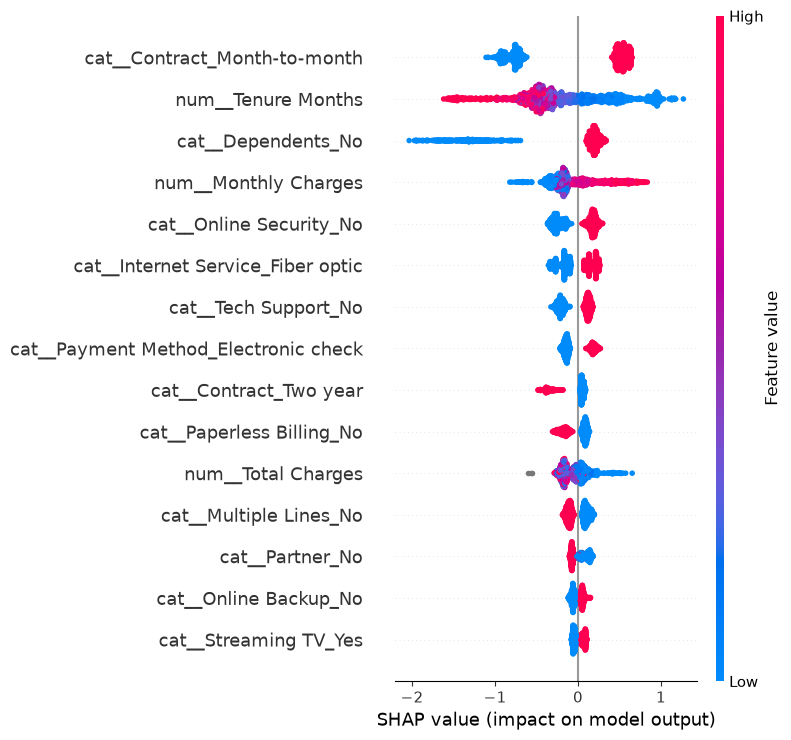

Saved ../results/shap_summary.png


In [8]:
import matplotlib.pyplot as plt

plt.figure()
shap.summary_plot(
    shap_values_test,
    X_test_processed_df,
    show=False,
    max_display=15,
)
plt.tight_layout()
plt.savefig("../results/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ../results/shap_summary.png")

### 5b. Ranked SHAP feature importance table (mean |SHAP value|)

Saved to `results/shap_feature_importance.csv` — deliberately named differently from Gracy's `results/xgboost_feature_importance.csv` (see note above), which is left untouched.

In [9]:
mean_abs_shap = np.abs(shap_values_test).mean(axis=0)

shap_importance_df = (
    pd.DataFrame({
        "feature": processed_feature_names,
        "mean_abs_shap_value": mean_abs_shap,
    })
    .sort_values("mean_abs_shap_value", ascending=False)
    .reset_index(drop=True)
)

shap_importance_df.to_csv("../results/shap_feature_importance.csv", index=False)
print("Saved ../results/shap_feature_importance.csv")
shap_importance_df.head(15)

Saved ../results/shap_feature_importance.csv


,feature,mean_abs_shap_value
0,cat__Contract_Month-to-month,0.654247
1,num__Tenure Months,0.500310
2,cat__Dependents_No,0.462295
3,num__Monthly Charges,0.254092
4,cat__Online Security_No,0.214866
5,cat__Internet Service_Fiber optic,0.191492
6,cat__Tech Support_No,0.167573
7,cat__Payment Method_Electronic check,0.159653
8,cat__Contract_Two year,0.124496
9,cat__Paperless Billing_No,0.121944


### 5c. SHAP bar plot (mean |SHAP value|)

Same ranking as the table above, shown as a bar chart for quick visual reference.

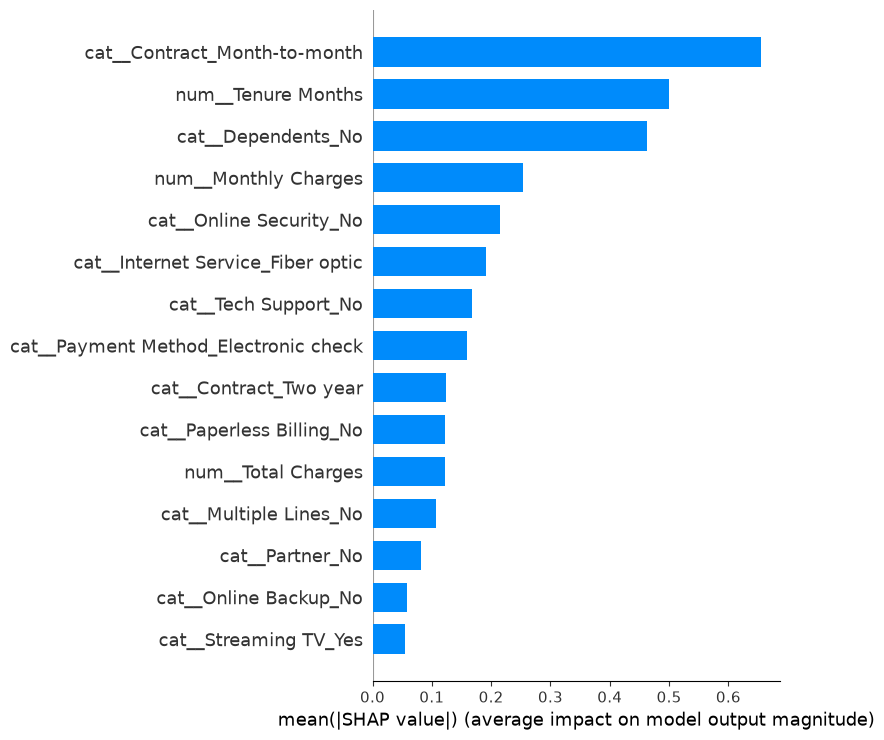

Saved ../results/shap_bar_importance.png


In [10]:
plt.figure()
shap.summary_plot(
    shap_values_test,
    X_test_processed_df,
    plot_type="bar",
    show=False,
    max_display=15,
)
plt.tight_layout()
plt.savefig("../results/shap_bar_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ../results/shap_bar_importance.png")

## 6. Local Explainability

To explain a single customer in business terms, the 47 processed SHAP columns first need to be mapped back to the 20 original raw features. A categorical feature like `Contract` produces three one-hot columns (`Contract_Month-to-month`, `Contract_One year`, `Contract_Two year`); TreeExplainer assigns each of the three its own SHAP value for every customer. Rather than reporting all three separately (confusing — a customer only ever has one active category), the SHAP values for a feature's one-hot columns are **summed** to get that feature's total contribution, and the customer's actual raw value (e.g. `"Month-to-month"`) is shown alongside it. Numeric features (already a single column) need no aggregation.

The mapping from processed column -> (original feature, category) is built directly from `preprocessor.named_transformers_["cat"].categories_`, in the same order `ColumnTransformer` concatenates them — not by parsing the generated string names — so it can't silently break on a feature value that happens to contain an underscore or extra text.

In [11]:
numeric_features = list(preprocessor_step.transformers_[0][2])
categorical_features = list(preprocessor_step.transformers_[1][2])
onehot_categories = preprocessor_step.named_transformers_["cat"].categories_

# processed_to_original[j] = (original_feature_name, category_or_None)
# aligned 1:1 with processed_feature_names / shap_values_test columns.
processed_to_original = [(f, None) for f in numeric_features]
for feature_name, categories in zip(categorical_features, onehot_categories):
    for category in categories:
        processed_to_original.append((feature_name, category))

assert len(processed_to_original) == len(processed_feature_names)
print("Mapping built for", len(processed_to_original), "processed columns.")
print("Example (numeric):", processed_to_original[0])
print("Example (categorical):", processed_to_original[len(numeric_features)])

Mapping built for 47 processed columns.
Example (numeric): ('Tenure Months', None)
Example (categorical): ('Gender', 'Female')


In [12]:
def get_top_shap_features(customer_row_index, top_n=5):
    """Aggregate SHAP values by original raw feature for one test customer.

    customer_row_index: the pandas index label of the customer in X_test
    (i.e. an index value from test_customers / X_test), not a positional int.

    Returns a DataFrame with one row per original feature: the customer's
    actual raw value, the aggregated SHAP contribution, and its direction.
    Sorted by absolute SHAP value, largest first; top_n controls how many
    rows to return (pass None for all 20 features).
    """
    position = X_test_processed_df.index.get_loc(customer_row_index)
    shap_row = shap_values_test[position]
    raw_row = X_test.loc[customer_row_index]

    contributions = {}
    for shap_value, (feature, _category) in zip(shap_row, processed_to_original):
        contributions[feature] = contributions.get(feature, 0.0) + shap_value

    records = [
        {
            "feature": feature,
            "customer_value": raw_row[feature],
            "shap_value": shap_value,
            "direction": "increases_risk" if shap_value > 0 else "decreases_risk",
        }
        for feature, shap_value in contributions.items()
    ]

    result = pd.DataFrame(records)
    result["abs_shap_value"] = result["shap_value"].abs()
    result = result.sort_values("abs_shap_value", ascending=False).drop(columns="abs_shap_value")
    return result.head(top_n) if top_n else result.reset_index(drop=True)


# Demo on the same sample customer used in Section 3.
demo_row_index = test_customers.index[0]
demo_features = get_top_shap_features(demo_row_index, top_n=None)
demo_features

,feature,customer_value,shap_value,direction
0,Tenure Months,72,-1.459831,decreases_risk
1,Contract,Two year,-1.232987,decreases_risk
2,Monthly Charges,114.05,0.594621,increases_risk
3,Online Security,Yes,-0.315786,decreases_risk
4,Dependents,No,0.272676,increases_risk
5,Tech Support,Yes,-0.216142,decreases_risk
6,Total Charges,8468.2,-0.147615,decreases_risk
7,Payment Method,Credit card (automatic),-0.138388,decreases_risk
8,Internet Service,Fiber optic,0.129201,increases_risk
9,Online Backup,Yes,-0.102194,decreases_risk


### 6a. Full local explanation for one customer

The demo customer above (`4376-KFVRS`) has very low predicted churn risk (3.30%), which makes a light example — most of its top drivers are risk-reducing. To also see a genuinely high-risk case, find the highest-probability customer in the test set and explain that one too. This uses only `predict_customer()` and `get_top_shap_features()` — nothing here is hard-coded or invented; every number traces back to the model and its SHAP values.

In [13]:
def explain_customer_local(customer_row_index, top_n=5):
    """Print a business-facing local explanation for one held-out test customer."""
    customer_id = test_customers.loc[customer_row_index, "CustomerID"]
    raw_features = X_test.loc[[customer_row_index]]
    prediction = predict_customer(raw_features)

    top_features = get_top_shap_features(customer_row_index, top_n=None)
    increasing = top_features[top_features["shap_value"] > 0].head(top_n)
    decreasing = top_features[top_features["shap_value"] < 0].sort_values("shap_value").head(top_n)

    print(f"Customer: {customer_id}")
    print(f"Predicted churn probability: {prediction['churn_probability']:.2%}")
    print(f"Decision (threshold {CHURN_THRESHOLD:.2f}): "
          f"{'High churn risk' if prediction['churn_prediction'] else 'Not classified as churn-risk'}")

    print("\nTop factors increasing churn risk:")
    for i, row in enumerate(increasing.itertuples(), 1):
        print(f"  {i}. {row.feature} = {row.customer_value} (SHAP contribution: {row.shap_value:+.3f})")

    print("\nTop factors reducing churn risk:")
    for i, row in enumerate(decreasing.itertuples(), 1):
        print(f"  {i}. {row.feature} = {row.customer_value} (SHAP contribution: {row.shap_value:+.3f})")

    return prediction, increasing, decreasing


# High-risk example: the test customer with the highest predicted churn probability.
all_probabilities = churn_pipeline.predict_proba(X_test)[:, 1]
highest_risk_row_index = X_test.index[np.argmax(all_probabilities)]

explain_customer_local(highest_risk_row_index)
print()
explain_customer_local(demo_row_index)

Customer: 5178-LMXOP
Predicted churn probability: 93.48%
Decision (threshold 0.30): High churn risk

Top factors increasing churn risk:
  1. Tenure Months = 1 (SHAP contribution: +0.980)
  2. Contract = Month-to-month (SHAP contribution: +0.623)
  3. Monthly Charges = 95.1 (SHAP contribution: +0.323)
  4. Internet Service = Fiber optic (SHAP contribution: +0.228)
  5. Total Charges = 95.1 (SHAP contribution: +0.220)

Top factors reducing churn risk:
  1. Phone Service = Yes (SHAP contribution: -0.011)
  2. Gender = Male (SHAP contribution: -0.008)

Customer: 4376-KFVRS
Predicted churn probability: 3.30%
Decision (threshold 0.30): Not classified as churn-risk

Top factors increasing churn risk:
  1. Monthly Charges = 114.05 (SHAP contribution: +0.595)
  2. Dependents = No (SHAP contribution: +0.273)
  3. Internet Service = Fiber optic (SHAP contribution: +0.129)
  4. Partner = Yes (SHAP contribution: +0.078)
  5. Paperless Billing = Yes (SHAP contribution: +0.065)

Top factors reducing 

({'churn_probability': 0.03303012251853943, 'churn_prediction': 0},
               feature customer_value  shap_value       direction
 2     Monthly Charges         114.05    0.594621  increases_risk
 4          Dependents             No    0.272676  increases_risk
 8    Internet Service    Fiber optic    0.129201  increases_risk
 11            Partner            Yes    0.077734  increases_risk
 12  Paperless Billing            Yes    0.065208  increases_risk,
            feature customer_value  shap_value       direction
 0    Tenure Months             72   -1.459831  decreases_risk
 1         Contract       Two year   -1.232987  decreases_risk
 3  Online Security            Yes   -0.315786  decreases_risk
 5     Tech Support            Yes   -0.216142  decreases_risk
 6    Total Charges         8468.2   -0.147615  decreases_risk)

## 7. Human-Readable Explanations

`generate_business_explanation()` converts one row from `get_top_shap_features()` (a real feature, the customer's real value, and its real SHAP contribution) into a plain-English sentence. It never invents a value or a reason: the sentence is built entirely from the `feature`/`customer_value`/`shap_value` it's given, so if a different customer or a different top feature comes in, the sentence changes accordingly.

Per Section 15 of the project brief, wording deliberately avoids causal language ("causes churn") in favor of "is contributing to a higher/lower predicted churn risk" — SHAP explains this model's output, not a real-world cause.

In [14]:
# Features whose values are simple Yes/No add-ons or attributes; phrased as
# "having" / "not having" <feature>. Everything else gets a feature-specific
# template below, or a generic fallback.
YES_NO_FEATURES = {
    "Online Security", "Online Backup", "Device Protection", "Tech Support",
    "Streaming TV", "Streaming Movies", "Multiple Lines", "Phone Service",
    "Paperless Billing", "Senior Citizen", "Dependents",
}

# Yes/No features phrased with a singular article ("a partner") rather than
# as a bare noun ("phone service").
YES_NO_FEATURES_WITH_ARTICLE = {"Partner"}


def generate_business_explanation(feature: str, customer_value, shap_value: float) -> str:
    """Turn one (feature, customer_value, shap_value) triple into a business sentence.

    Never hard-codes a generic sentence that ignores the inputs — the
    feature name and the customer's actual value are always what's spoken
    about, and direction always comes from the sign of shap_value.
    """
    risk_word = "higher" if shap_value > 0 else "lower"

    if feature in YES_NO_FEATURES_WITH_ARTICLE and customer_value in ("Yes", "No"):
        has_clause = "having a" if customer_value == "Yes" else "not having a"
        return (f"The customer {has_clause} {feature.lower()} is contributing "
                f"to a {risk_word} predicted churn risk.")

    if feature in YES_NO_FEATURES and customer_value in ("Yes", "No"):
        has_clause = "having" if customer_value == "Yes" else "not having"
        return (f"The customer {has_clause} {feature.lower()} is contributing "
                f"to a {risk_word} predicted churn risk.")

    if feature == "Contract":
        return (f"The customer's {str(customer_value).lower()} contract is "
                f"contributing to a {risk_word} predicted churn risk.")

    if feature == "Tenure Months":
        unit = "month" if customer_value == 1 else "months"
        return (f"The customer's tenure of {customer_value} {unit} is "
                f"contributing to a {risk_word} predicted churn risk.")

    if feature == "Monthly Charges":
        return (f"The customer's monthly charge of ${float(customer_value):.2f} is "
                f"contributing to a {risk_word} predicted churn risk.")

    if feature == "Total Charges":
        return (f"The customer's total charges to date (${float(customer_value):.2f}) are "
                f"contributing to a {risk_word} predicted churn risk.")

    if feature == "CLTV":
        return (f"The customer's customer lifetime value score ({customer_value}) is "
                f"contributing to a {risk_word} predicted churn risk.")

    if feature in ("Internet Service", "Payment Method", "Gender"):
        return (f"The customer's {feature.lower()} ('{customer_value}') is "
                f"contributing to a {risk_word} predicted churn risk.")

    return (f"The customer's {feature.lower()} ('{customer_value}') is "
            f"contributing to a {risk_word} predicted churn risk.")


# Spot-check against the two spec examples from the project brief.
print(generate_business_explanation("Contract", "Month-to-month", 0.62))
print(generate_business_explanation("Tenure Months", 72, -1.46))
print(generate_business_explanation("Tenure Months", 1, 0.98))
print(generate_business_explanation("Partner", "Yes", 0.08))
print(generate_business_explanation("Dependents", "No", 0.27))

The customer's month-to-month contract is contributing to a higher predicted churn risk.
The customer's tenure of 72 months is contributing to a lower predicted churn risk.
The customer's tenure of 1 month is contributing to a higher predicted churn risk.
The customer having a partner is contributing to a higher predicted churn risk.
The customer not having dependents is contributing to a higher predicted churn risk.


In [15]:
def explain_customer_business(customer_row_index, top_n=5):
    """Full business-readable explanation for one customer: probability,
    decision, and human-readable sentences for the top increasing/decreasing
    churn drivers. Everything is derived from predict_customer() and
    get_top_shap_features() — no invented values or explanations.
    """
    raw_features = X_test.loc[[customer_row_index]]
    prediction = predict_customer(raw_features)

    top_features = get_top_shap_features(customer_row_index, top_n=None)
    increasing = top_features[top_features["shap_value"] > 0].head(top_n)
    decreasing = top_features[top_features["shap_value"] < 0].sort_values("shap_value").head(top_n)

    increasing_sentences = [
        generate_business_explanation(row.feature, row.customer_value, row.shap_value)
        for row in increasing.itertuples()
    ]
    decreasing_sentences = [
        generate_business_explanation(row.feature, row.customer_value, row.shap_value)
        for row in decreasing.itertuples()
    ]

    return {
        "customer_id": test_customers.loc[customer_row_index, "CustomerID"],
        "churn_probability": prediction["churn_probability"],
        "churn_prediction": prediction["churn_prediction"],
        "increasing_risk_explanations": increasing_sentences,
        "decreasing_risk_explanations": decreasing_sentences,
    }


for row_index in (highest_risk_row_index, demo_row_index):
    explanation = explain_customer_business(row_index)
    print(f"Customer: {explanation['customer_id']}")
    print(f"Predicted churn probability: {explanation['churn_probability']:.2%}")
    print(f"Decision: {'High churn risk' if explanation['churn_prediction'] else 'Not classified as churn-risk'}")
    print("\nWhy risk is higher:")
    for sentence in explanation["increasing_risk_explanations"]:
        print(" -", sentence)
    print("\nWhy risk is lower:")
    for sentence in explanation["decreasing_risk_explanations"]:
        print(" -", sentence)
    print("\n" + "=" * 80 + "\n")

Customer: 5178-LMXOP
Predicted churn probability: 93.48%
Decision: High churn risk

Why risk is higher:
 - The customer's tenure of 1 month is contributing to a higher predicted churn risk.
 - The customer's month-to-month contract is contributing to a higher predicted churn risk.
 - The customer's monthly charge of $95.10 is contributing to a higher predicted churn risk.
 - The customer's internet service ('Fiber optic') is contributing to a higher predicted churn risk.
 - The customer's total charges to date ($95.10) are contributing to a higher predicted churn risk.

Why risk is lower:
 - The customer having phone service is contributing to a lower predicted churn risk.
 - The customer's gender ('Male') is contributing to a lower predicted churn risk.


Customer: 4376-KFVRS
Predicted churn probability: 3.30%
Decision: Not classified as churn-risk

Why risk is higher:
 - The customer's monthly charge of $114.05 is contributing to a higher predicted churn risk.
 - The customer not hav

## 8. Churn Driver Classification

Not every SHAP-flagged driver is something the business can act on. `Gender`, `Senior Citizen`, and `CLTV` (a computed score, not a lever itself) sometimes show up among a customer's top SHAP contributors, but there's no retention offer for "the customer's gender" — recommending against a demographic trait would be inappropriate and pointless. This step classifies each of the 20 raw features as **actionable** (a real product/plan/service lever the business can change) or **non-actionable** (a fixed customer attribute), so Section 9's recommendation engine only ever proposes actions for actionable drivers.

In [16]:
# Fixed customer attributes: not something a retention offer can change.
NON_ACTIONABLE_FEATURES = {"Gender", "Senior Citizen", "Partner", "Dependents", "CLTV"}

# Everything else is a plan/product/service lever the business can act on.
ACTIONABLE_FEATURES = set(FEATURES) - NON_ACTIONABLE_FEATURES

print("Actionable features (", len(ACTIONABLE_FEATURES), "):", sorted(ACTIONABLE_FEATURES))
print("\nNon-actionable features (", len(NON_ACTIONABLE_FEATURES), "):", sorted(NON_ACTIONABLE_FEATURES))


def classify_driver(feature: str) -> str:
    """Classify a raw feature as an actionable business lever or a fixed attribute."""
    return "actionable" if feature in ACTIONABLE_FEATURES else "non_actionable"


# Apply to the high-risk demo customer's top drivers to see the split in practice.
demo_classified = get_top_shap_features(highest_risk_row_index, top_n=None)
demo_classified["classification"] = demo_classified["feature"].apply(classify_driver)
demo_classified.head(10)

Actionable features ( 15 ): ['Contract', 'Device Protection', 'Internet Service', 'Monthly Charges', 'Multiple Lines', 'Online Backup', 'Online Security', 'Paperless Billing', 'Payment Method', 'Phone Service', 'Streaming Movies', 'Streaming TV', 'Tech Support', 'Tenure Months', 'Total Charges']

Non-actionable features ( 5 ): ['CLTV', 'Dependents', 'Gender', 'Partner', 'Senior Citizen']


,feature,customer_value,shap_value,direction,classification
0,Tenure Months,1,0.980074,increases_risk,actionable
1,Contract,Month-to-month,0.623013,increases_risk,actionable
2,Monthly Charges,95.1,0.322762,increases_risk,actionable
3,Internet Service,Fiber optic,0.227777,increases_risk,actionable
4,Total Charges,95.1,0.219851,increases_risk,actionable
5,Dependents,No,0.196785,increases_risk,non_actionable
6,Payment Method,Electronic check,0.189200,increases_risk,actionable
7,Tech Support,No,0.172798,increases_risk,actionable
8,Multiple Lines,Yes,0.166328,increases_risk,actionable
9,Online Security,No,0.165422,increases_risk,actionable


## 9. Retention Recommendation Logic

`RECOMMENDATION_RULES` is a transparent, rule-based mapping from an actionable churn driver to a retention action — not something learned by XGBoost. The model only predicts churn probability; this table is a separate, hand-authored business layer that translates the *drivers SHAP already identified* into an action, so every recommendation is directly traceable back to the specific feature (and the customer's specific value) that triggered it.

Rules only fire for a driver that is (a) actionable (Section 8) and (b) currently *increasing* this customer's risk (a driver already reducing risk, e.g. `Contract = Two year`, needs no action). A feature without an explicit rule below gets a clearly-labeled generic fallback rather than a silently missing recommendation.

In [17]:
# feature -> function(customer_value) -> recommended action.
# Each rule reads the customer's actual value so the same feature can
# produce a different action for a different value where that matters
# (e.g. Contract), rather than a single fixed string per feature.
RECOMMENDATION_RULES = {
    "Contract": lambda v: (
        "Offer an incentive (discount or perk) to move from month-to-month "
        "to an annual or two-year contract."
        if v == "Month-to-month" else
        f"Review the customer's current contract ('{v}') ahead of renewal."
    ),
    "Online Security": lambda v: (
        "Offer an online security add-on/bundle."
        if v == "No" else f"Review the customer's online security plan (currently '{v}')."
    ),
    "Online Backup": lambda v: (
        "Offer an online backup add-on/bundle."
        if v == "No" else f"Review the customer's online backup plan (currently '{v}')."
    ),
    "Device Protection": lambda v: (
        "Offer a device protection add-on/bundle."
        if v == "No" else f"Review the customer's device protection plan (currently '{v}')."
    ),
    "Tech Support": lambda v: (
        "Offer a tech support package."
        if v == "No" else f"Review the customer's tech support plan (currently '{v}')."
    ),
    "Multiple Lines": lambda v: (
        "Offer a multiple-lines bundle discount."
        if v == "No" else f"Review the customer's lines plan (currently '{v}')."
    ),
    "Monthly Charges": lambda v: (
        f"Review the customer's plan/pricing (current monthly charge ${float(v):.2f}) "
        "or offer a personalized pricing/discount review."
    ),
    "Total Charges": lambda v: (
        "Review the customer's overall billing history for a loyalty or pricing offer."
    ),
    "Tenure Months": lambda v: (
        "Enroll the customer in an onboarding / early-engagement retention program."
        if float(v) <= 12 else
        "Schedule a loyalty check-in given the customer's tenure."
    ),
    "Internet Service": lambda v: (
        f"Review the customer's internet plan ('{v}') for a better-fit offer or service quality check."
    ),
    "Payment Method": lambda v: (
        "Encourage a switch to automatic payment (credit card / bank transfer) for reliability."
        if v == "Electronic check" else
        f"Review the customer's payment method (currently '{v}')."
    ),
    "Paperless Billing": lambda v: (
        "Confirm the customer is comfortable with paperless billing and offer support if needed."
    ),
    "Phone Service": lambda v: (
        "Review the customer's phone service plan for a better-fit bundle."
    ),
    "Streaming TV": lambda v: (
        "Review the customer's streaming TV add-on and bundle pricing."
    ),
    "Streaming Movies": lambda v: (
        "Review the customer's streaming movies add-on and bundle pricing."
    ),
}


def generate_recommendations(customer_row_index, top_n=5):
    """Map a customer's top actionable, risk-increasing SHAP drivers to
    retention actions. Returns a list of dicts, each traceable to one
    driver: {driver, customer_value, shap_value, action}. Non-actionable
    drivers (Section 8) and risk-reducing drivers never produce a
    recommendation here.
    """
    top_features = get_top_shap_features(customer_row_index, top_n=None)
    top_features = top_features[top_features["feature"].isin(ACTIONABLE_FEATURES)]
    increasing = top_features[top_features["shap_value"] > 0].head(top_n)

    recommendations = []
    for row in increasing.itertuples():
        rule = RECOMMENDATION_RULES.get(row.feature)
        if rule is not None:
            action = rule(row.customer_value)
        else:
            action = (f"Flag '{row.feature}' (current value '{row.customer_value}') "
                      "for personalized retention review with the customer.")
        recommendations.append({
            "driver": row.feature,
            "customer_value": row.customer_value,
            "shap_value": row.shap_value,
            "action": action,
        })
    return recommendations


# Demo on the high-risk customer from earlier sections.
for rec in generate_recommendations(highest_risk_row_index):
    print(f"- Driver: {rec['driver']} = {rec['customer_value']} (SHAP {rec['shap_value']:+.3f})")
    print(f"  Action: {rec['action']}\n")

- Driver: Tenure Months = 1 (SHAP +0.980)
  Action: Enroll the customer in an onboarding / early-engagement retention program.

- Driver: Contract = Month-to-month (SHAP +0.623)
  Action: Offer an incentive (discount or perk) to move from month-to-month to an annual or two-year contract.

- Driver: Monthly Charges = 95.1 (SHAP +0.323)
  Action: Review the customer's plan/pricing (current monthly charge $95.10) or offer a personalized pricing/discount review.

- Driver: Internet Service = Fiber optic (SHAP +0.228)
  Action: Review the customer's internet plan ('Fiber optic') for a better-fit offer or service quality check.

- Driver: Total Charges = 95.1 (SHAP +0.220)
  Action: Review the customer's overall billing history for a loyalty or pricing offer.



## 10. Example Customer Explanations

Per the project brief's testing requirements (Section 20), the full pipeline — `predict_customer()` -> `get_top_shap_features()` -> `generate_business_explanation()` -> `generate_recommendations()` — is run end-to-end on three genuinely different held-out customers:

- **Example A — High predicted churn risk**: the highest-probability customer in the test set (already used throughout Sections 6-9).
- **Example B — Low predicted churn risk**: the lowest-probability customer in the test set.
- **Example C — Near the 0.30 threshold**: the test customer whose predicted probability is closest to 0.30, i.e. a genuinely borderline case rather than an obvious high/low example.

In [18]:
lowest_risk_row_index = X_test.index[np.argmin(all_probabilities)]
near_threshold_row_index = X_test.index[np.argmin(np.abs(all_probabilities - CHURN_THRESHOLD))]

example_customers = {
    "Example A (high risk)": highest_risk_row_index,
    "Example B (low risk)": lowest_risk_row_index,
    "Example C (near threshold)": near_threshold_row_index,
}


def print_full_customer_report(customer_row_index):
    business = explain_customer_business(customer_row_index)
    recommendations = generate_recommendations(customer_row_index)

    print(f"Customer: {business['customer_id']}")
    print(f"Predicted churn probability: {business['churn_probability']:.2%}")
    print(f"Decision (threshold {CHURN_THRESHOLD:.2f}): "
          f"{'High churn risk' if business['churn_prediction'] else 'Not classified as churn-risk'}")

    print("\nWhy risk is higher:")
    for sentence in business["increasing_risk_explanations"]:
        print(" -", sentence)

    print("\nWhy risk is lower:")
    for sentence in business["decreasing_risk_explanations"]:
        print(" -", sentence)

    print("\nRecommended retention actions:")
    if recommendations:
        for rec in recommendations:
            print(f" - [{rec['driver']} = {rec['customer_value']}] {rec['action']}")
    else:
        print(" - No actionable risk-increasing drivers identified.")


for label, row_index in example_customers.items():
    print("=" * 80)
    print(label)
    print("=" * 80)
    print_full_customer_report(row_index)
    print()

Example A (high risk)
Customer: 5178-LMXOP
Predicted churn probability: 93.48%
Decision (threshold 0.30): High churn risk

Why risk is higher:
 - The customer's tenure of 1 month is contributing to a higher predicted churn risk.
 - The customer's month-to-month contract is contributing to a higher predicted churn risk.
 - The customer's monthly charge of $95.10 is contributing to a higher predicted churn risk.
 - The customer's internet service ('Fiber optic') is contributing to a higher predicted churn risk.
 - The customer's total charges to date ($95.10) are contributing to a higher predicted churn risk.

Why risk is lower:
 - The customer having phone service is contributing to a lower predicted churn risk.
 - The customer's gender ('Male') is contributing to a lower predicted churn risk.

Recommended retention actions:
 - [Tenure Months = 1] Enroll the customer in an onboarding / early-engagement retention program.
 - [Contract = Month-to-month] Offer an incentive (discount or per

Customer: 0794-YVSGE
Predicted churn probability: 0.17%
Decision (threshold 0.30): Not classified as churn-risk

Why risk is higher:
 - The customer having a partner is contributing to a higher predicted churn risk.
 - The customer's gender ('Male') is contributing to a higher predicted churn risk.

Why risk is lower:
 - The customer's two year contract is contributing to a lower predicted churn risk.
 - The customer's tenure of 72 months is contributing to a lower predicted churn risk.
 - The customer having dependents is contributing to a lower predicted churn risk.
 - The customer's monthly charge of $20.30 is contributing to a lower predicted churn risk.
 - The customer's tech support ('No internet service') is contributing to a lower predicted churn risk.

Recommended retention actions:
 - No actionable risk-increasing drivers identified.

Example C (near threshold)
Customer: 9812-GHVRI
Predicted churn probability: 30.02%
Decision (threshold 0.30): High churn risk

Why risk is hig

## 11. XAI Validation / Sanity Checks

Automated checks against the three example customers above (Section 20 of the project brief), covering every point it lists: valid probability, prediction agrees with the threshold, the SHAP explanation actually corresponds to the model's output, top drivers are genuinely derived from SHAP (not invented), recommendations correspond to identified drivers, and no unsupported causal claims appear in the generated text.

In [19]:
CAUSAL_PHRASES = ["causes", "cause churn", "leads to churn", "results in churn", "will churn"]


def validate_customer_explanation(customer_row_index):
    """Run all Section 20 checks for one customer; raises AssertionError on failure."""
    raw_features = X_test.loc[[customer_row_index]]
    prediction = predict_customer(raw_features)
    probability = prediction["churn_probability"]

    # 1. Probability is valid.
    assert 0.0 <= probability <= 1.0, f"Invalid probability: {probability}"

    # 2. Prediction agrees with the threshold.
    expected_prediction = int(probability >= CHURN_THRESHOLD)
    assert prediction["churn_prediction"] == expected_prediction, "Prediction does not match threshold rule"

    # 3. SHAP explanation corresponds to the model's actual output: for this
    #    customer, base_value + sum(all 47 raw SHAP values) must reconstruct
    #    the model's raw margin.
    position = X_test_processed_df.index.get_loc(customer_row_index)
    shap_row = shap_values_test[position]
    raw_margin = xgb_step.predict(X_test_processed_df.iloc[[position]], output_margin=True)[0]
    reconstructed_margin = explainer.expected_value + shap_row.sum()
    assert np.isclose(raw_margin, reconstructed_margin, atol=1e-4), (
        f"SHAP values do not reconstruct model output: {raw_margin} vs {reconstructed_margin}"
    )

    # 4. Top drivers are genuinely derived from SHAP: recomputed aggregation
    #    must match get_top_shap_features()'s own aggregation exactly, and
    #    every row's direction must match the sign of its shap_value.
    top_features = get_top_shap_features(customer_row_index, top_n=None)
    assert len(top_features) == len(FEATURES), "Unexpected number of aggregated features"
    for row in top_features.itertuples():
        expected_direction = "increases_risk" if row.shap_value > 0 else "decreases_risk"
        assert row.direction == expected_direction, f"Direction/sign mismatch for {row.feature}"
    assert top_features["shap_value"].abs().is_monotonic_decreasing, "Top features not sorted by |SHAP value|"

    # 5. Recommendations correspond to identified, actionable, risk-increasing drivers.
    recommendations = generate_recommendations(customer_row_index)
    increasing_actionable_features = set(
        top_features[(top_features["shap_value"] > 0) & (top_features["feature"].isin(ACTIONABLE_FEATURES))]["feature"]
    )
    for rec in recommendations:
        assert rec["driver"] in ACTIONABLE_FEATURES, f"Recommendation for non-actionable driver: {rec['driver']}"
        assert rec["driver"] in increasing_actionable_features, (
            f"Recommendation driver {rec['driver']} is not an identified risk-increasing driver"
        )
        assert rec["shap_value"] > 0, f"Recommendation driver {rec['driver']} does not increase risk"

    # 6. No unsupported causal claims in the generated business explanations.
    business = explain_customer_business(customer_row_index)
    all_sentences = business["increasing_risk_explanations"] + business["decreasing_risk_explanations"]
    for sentence in all_sentences:
        lowered = sentence.lower()
        for phrase in CAUSAL_PHRASES:
            assert phrase not in lowered, f"Causal language found: '{sentence}'"

    return True


for label, row_index in example_customers.items():
    validate_customer_explanation(row_index)
    print(f"PASS: {label} (CustomerID {test_customers.loc[row_index, 'CustomerID']})")

print("\nAll Section 20 checks passed for Examples A, B, and C.")

PASS: Example A (high risk) (CustomerID 5178-LMXOP)


PASS: Example B (low risk) (CustomerID 0794-YVSGE)


PASS: Example C (near threshold) (CustomerID 9812-GHVRI)

All Section 20 checks passed for Examples A, B, and C.


## 12. Conclusion